# **Регрессионная модель для SI**


**Импортируем необходимые библиотеки**

In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from catboost import CatBoostRegressor

**Загружаем данные**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')

targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['log_SI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'Train: X = {X_train.shape}, y = {y_train.shape}')
print(f'Test: X = {X_test.shape},  y = {y_test.shape}')
print(f'Статистика log_SI: mean = {y.mean():.3f}, std = {y.std():.3f}, min = {y.min():.3f}, max = {y.max():.3f}')

Данные для задачи log_SI загружены.
Train: X = (800, 139), y = (800,)
Test : X = (201, 139),  y = (201,)
Статистика log_SI: mean=0.743, std=0.754, min=-1.940, max=4.194


Вывод: целью данного этапа является построение модели для индекса селективности. Поскольку SI является производной величиной, его зависимость от структурных дескрипторов носит сложный и нелинейный характер. Логарифмическое преобразование logSI стабилизирует дисперсию, поэтому используем его в качестве целевой переменной.

**Обучаем модели**

In [ ]:
pipelines = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR())
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state = 42, n_jobs = -1))
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CatBoostRegressor(random_state = 42, verbose = 0))
    ]),
}

param_grids = {
    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    'SVR': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__border_count': [32, 64, 128],
        'model__iterations': [100, 300],
        'model__learning_rate': [0.05, 0.1]
    },
}

results = []
best_models = {}

print('Обучение моделей (GridSearchCV, cv = 5)')

for name in pipelines:
    gs = GridSearchCV(pipelines[name], param_grids[name], cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_

    y_pred = gs.best_estimator_.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(gs.best_params_),
        'R^2': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4),
    })
    print(f'R^2={r2:.4f}')

results_df = (pd.DataFrame(results).sort_values('R^2', ascending=False).reset_index(drop=True))

print('Результаты базовых моделей (log_SI)')
display(results_df)

Обучение моделей (GridSearchCV, cv=5)
R^2=0.1204
R^2=0.2382
R^2=0.2693
R^2=0.2826
Результаты базовых моделей (log_SI)


,Модель,Лучшие гиперпараметры,R^2,MSE,MAE
0,CatBoost,"{'model__border_count': 32, 'model__depth': 8,...",0.2826,0.4377,0.4970
1,RandomForest,"{'model__max_depth': 10, 'model__min_samples_s...",0.2693,0.4458,0.4949
2,SVR,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.2382,0.4648,0.4902
3,Ridge,{'model__alpha': 100.0},0.1204,0.5366,0.5551


Показатель R^2 достаточно низкий у всех моделей. SI = CC50 / IC50 - это соотношение двух шумных переменных. Когда числитель и знаменатель предсказываются с ошибкой, их соотношение предсказывается еще хуже. Это фундаментальное ограничение. К тому же SI имеет сильно правостороннее распределение. Даже после log-трансформации хвосты распределения остаются сложными. Также датасет достаточно небольшой, и модели не хватает данных.
CatBoost справился с задачей лучше других моделей. Он настраивался по параметрам depth и border_count: они контролируют сложность деревьев и точность разбиения числовых признаков, что особенно важно для редких значений в хвостах распределения.

**Визуализируем результаты**

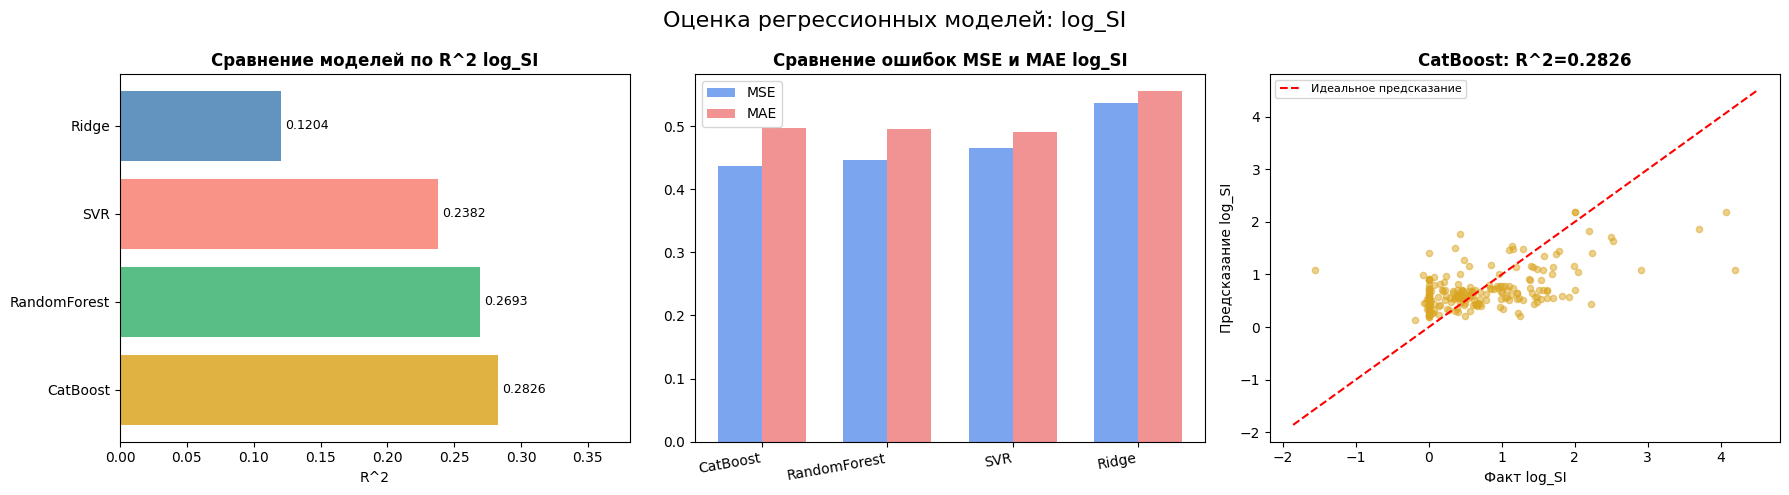

In [ ]:
model_colors = {
    'Ridge': 'steelblue',
    'SVR': 'salmon',
    'RandomForest': 'mediumseagreen',
    'CatBoost': 'goldenrod'
}

fig, axes = plt.subplots(1, 3, figsize = (18, 5))
fig.subplots_adjust(wspace=0.35)

#строим график R^2 по моделям
bars = axes[0].barh(
    results_df['Модель'],
    results_df['R^2'],
    color = results_df['Модель'].map(model_colors),
    alpha = 0.85
)
axes[0].set_xlabel('R^2')
axes[0].set_title('Сравнение моделей по R^2 log_SI', fontweight = 'bold')
axes[0].set_xlim(0, max(results_df['R^2']) * 1.35)
for bar, val in zip(bars, results_df['R^2']):
    axes[0].text(bar.get_width() + 0.003,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va = 'center', fontsize = 9)

#строим график по MSE и MAE
x = np.arange(len(results_df))
w = 0.35
axes[1].bar(x - w/2, results_df['MSE'], w, label = 'MSE', alpha = 0.85, color = 'cornflowerblue')
axes[1].bar(x + w/2, results_df['MAE'], w, label = 'MAE', alpha = 0.85, color = 'lightcoral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Модель'], rotation = 10, ha = 'right')
axes[1].set_title('Сравнение ошибок MSE и MAE log_SI', fontweight = 'bold')
axes[1].legend()

#строим график соответствия предсказания лучшей модели факту
best_name   = results_df.iloc[0]['Модель']
y_pred_best = best_models[best_name].predict(X_test)

axes[2].scatter(y_test, y_pred_best, alpha = 0.5, s = 20, color = model_colors.get(best_name, 'gray'))
lims = [min(y_test.min(), y_pred_best.min()) - 0.3,
        max(y_test.max(), y_pred_best.max()) + 0.3]
axes[2].plot(lims, lims, 'r--', lw = 1.5, label = 'Идеальное предсказание')
axes[2].set_xlabel('Факт log_SI')
axes[2].set_ylabel('Предсказание log_SI')
axes[2].set_title(f'{best_name}: R^2 = {results_df.iloc[0]["R^2"]:.4f}', fontweight = 'bold')
axes[2].legend(fontsize=8)

plt.suptitle('Оценка регрессионных моделей: log_SI', fontsize=16)
plt.tight_layout()
plt.show()

log_SI имеет тяжелые хвосты распределения: большинство соединений сосредоточено в центре, но есть редкие выбросы с очень высокой или очень низкой селективностью. Random Forest усредняет предсказания всех деревьев, поэтому на редких крайних значениях он тянет ответ к центру. CatBoost за счет настройки border_count строит более точные разбиения в зонах с малым числом объектов, что дает ему преимущество на хвостах.

**Выбираем самые важные признаки, оказывающие влияние на результаты Random Forest и CatBoost**

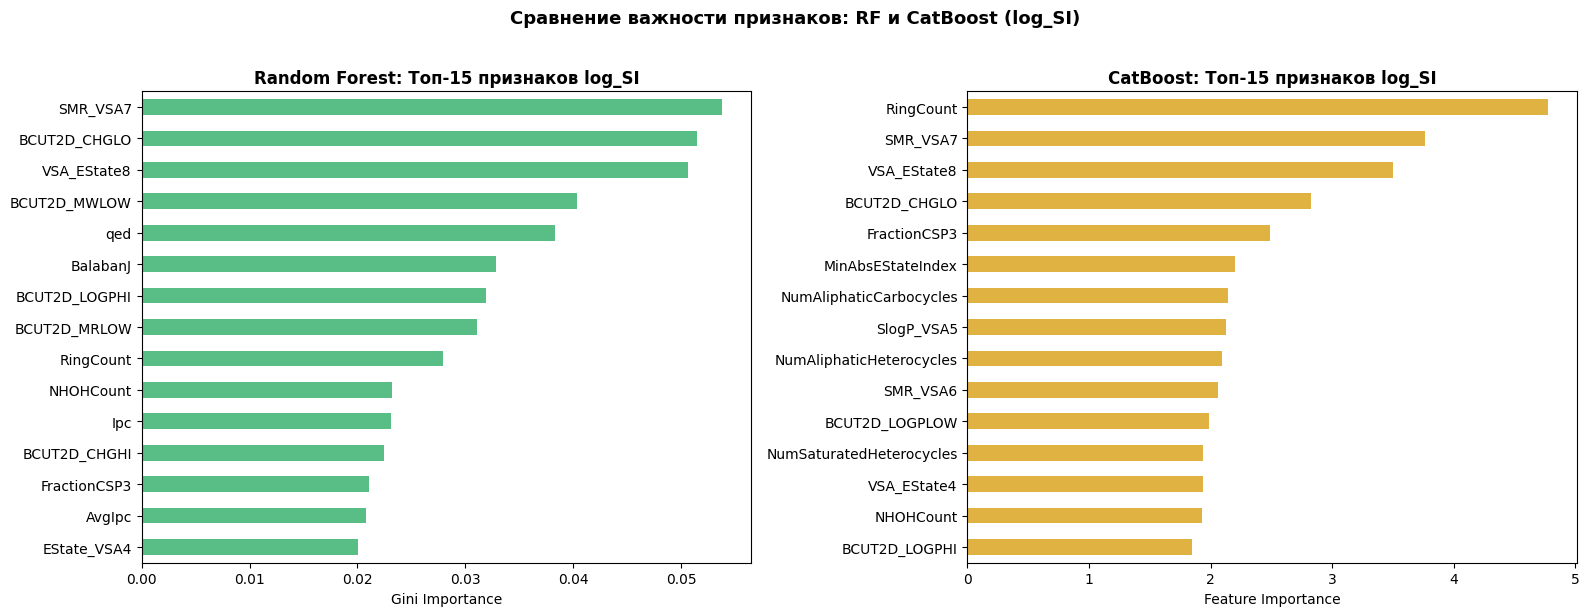

In [ ]:
rf_imp = pd.Series(
    best_models['RandomForest'].named_steps['model'].feature_importances_,
    index = X.columns
).sort_values(ascending=False).head(15)

cb_imp = pd.Series(
    best_models['CatBoost'].named_steps['model'].get_feature_importance(),
    index = X.columns
).sort_values(ascending = False).head(15)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

rf_imp[::-1].plot(kind = 'barh', ax = axes[0], color = 'mediumseagreen', alpha = 0.85)
axes[0].set_title('Random Forest: Топ-15 признаков log_SI', fontweight = 'bold')
axes[0].set_xlabel('Gini Importance')

cb_imp[::-1].plot(kind = 'barh', ax = axes[1], color = 'goldenrod', alpha = 0.85)
axes[1].set_title('CatBoost: Топ-15 признаков log_SI', fontweight = 'bold')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Сравнение важности признаков: RF и CatBoost (log_SI)', fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()

Вывод: в обоих топ-15 есть признаки, отвечающие за липофильность, поверхностную доступность и электронное строение молекулы (параметры SMR_VSA7, VSA_EState8, BCUT2D_CHGLO, RingCount, FractionCSP3, NHOHCount). Они определяют селективность. Их согласованность - хороший знак. 

RF выделяет BCUT2D_MWLOW, qed, BalabanJ - глобальные молекулярные характеристики - как важные признаки. CatBoost выбирает NumAliphaticCarbocycles, NumAliphaticHeterocycles, NumSaturatedHeterocycles - структуру колец. Это говорит о том, что число и тип кольцевых систем влияет на селективность, но RF не улавливает этот показатель. RF склонен размывать важность по большому числу признаков, тогда как CatBoost концентрирует ее на действительно разделяющих признаках. Поэтому CatBoost оказывается точнее.

**Итоговые выводы и рекомендации**

Финальная модель: CatBoost: R^2 = 0.2826, MSE = 0.44, MAE = 0.49
Рекомендации:
- расширить выборку. Текущее соотношение объектов к признакам составляет примерно 6:1 (800 объектов, 139 признаков), что существенно ниже рекомендуемого минимума 10:1. При таком соотношении любая модель переобучается на шуме. Удвоение выборки способно дать прирост коэффициенту детерминации более значительный, чем любые улучшения алгоритма.

- отбрать признаки на основе importance. RF и CatBoost согласуются в топ-10 признаках: SMR_VSA7, VSA_EState8, BCUT2D_CHGLO, RingCount, FractionCSP3, NHOHCount. Следует оставить топ-30–50 согласованных признаков и удалить остальные - это снизит шум и улучшит предсказание.

- настроить CatBoost через Optuna. GridSearchCV перебрал фиксированную сетку. Optuna с байесовской оптимизацией позволит точнее подобрать depth, learning_rate, l2_leaf_reg и border_count за меньшее число итераций - это может помочь улучшить R^2 без новых данных.

- отдельно исследовать log_SI > 3 и < -1. На графике "Факт/Предсказание" видно, что модель хорошо работает в диапазоне [0, 2], но систематически ошибается при log_SI > 3 и < -1. Возможно, они образуют структурно отдельный кластер, требующий специализированной модели.

- добавить дополнительные признаки, кодирующие клеточную проницаемость и мембранное связывание (TPSA, LogP-related дескрипторы) - они напрямую связаны с цитотоксичностью и могут улучшить предсказание числителя SI.